# Baking the PST / PAGE phase kernels into ROM

The PhyCV edge transforms multiply each spatial-frequency sample by a fixed phase coefficient
$C(\boldsymbol\rho)=L(\rho)\,e^{\,i\phi(\rho)}$. On an FPGA that is an **FFT-domain filter**: the
coefficients live in block-RAM and the pipeline multiplies as samples stream by. The naive table is the
full 2-D mask ($N^2$ complex numbers). But the **PST kernel is isotropic** -- it depends only on the radius
$\rho$ -- so the whole mask collapses to a **1-D radial ROM**: store $C(\rho)$ in a few hundred bins and
address it by $\rho(u,v)$. For a $200\times200$ frame that is $2\times256$ bytes instead of $40{,}000$
complex numbers.

**PAGE** adds orientation: its kernel is $\phi_r(\rho)\,D_k(\theta)$, so a second **1-D angular ROM**
$D_k(\theta)$ multiplies the radial one -- two small tables reconstruct the whole oriented bank.

This notebook builds the quantized **int8 radial cos/sin ROM**, shows the ROM'd kernel still detects edges
(contrast within a few percent of the float kernel), extends it to the PAGE angular ROM, then generates the
**VHDL coefficient ROM** and verifies it in **Icarus Verilog**. Self-contained: NumPy, Matplotlib, plus
`iverilog`/`vvp`.

In [1]:
import numpy as np, pandas as pd, sympy as sp
import matplotlib.pyplot as plt
from types import SimpleNamespace
from fractions import Fraction

# --- physical constants (CODATA 2018, SI) ------------------------------------
C = SimpleNamespace(
    C=299792458.0, H=6.62607015e-34, HBAR=6.62607015e-34/(2*np.pi), E=1.602176634e-19,
    K_B=1.380649e-23, N_A=6.02214076e23, EPS0=8.8541878128e-12, MU0=1.25663706212e-6,
    M_E=9.1093837015e-31, M_P=1.67262192369e-27, A0=5.29177210903e-11,
    RYDBERG_EV=13.605693122994, R_INF=10973731.568160, MU_B=9.2740100783e-24,
    ALPHA=7.2973525693e-3, EV=1.602176634e-19, NM=1e-9)
C.COULOMB_K = 1.0/(4*np.pi*C.EPS0)
C.table = lambda: pd.DataFrame(
    [("c",C.C,"m/s"),("h",C.H,"J s"),("hbar",C.HBAR,"J s"),("e",C.E,"C"),("k_B",C.K_B,"J/K"),
     ("N_A",C.N_A,"1/mol"),("eps0",C.EPS0,"F/m"),("m_e",C.M_E,"kg"),("m_p",C.M_P,"kg"),
     ("a0",C.A0,"m"),("Ry",C.RYDBERG_EV,"eV"),("mu_B",C.MU_B,"J/T"),("alpha",C.ALPHA,"1")],
    columns=["symbol","value_SI","unit"])

# --- dimensional analysis over the seven SI base quantities ------------------
_BASE = ("L","M","T","I","K","N","J")
class Dimension:
    __slots__=("e",)
    def __init__(s,**k): s.e={b:Fraction(k.get(b,0)) for b in _BASE}
    def __mul__(s,o): return Dimension(**{b:s.e[b]+o.e[b] for b in _BASE})
    def __truediv__(s,o): return Dimension(**{b:s.e[b]-o.e[b] for b in _BASE})
    def __pow__(s,p): p=Fraction(p); return Dimension(**{b:s.e[b]*p for b in _BASE})
    def __eq__(s,o): return isinstance(o,Dimension) and s.e==o.e
    def __hash__(s): return hash(tuple(s.e[b] for b in _BASE))
    @property
    def is_dimensionless(s): return all(v==0 for v in s.e.values())
    def __repr__(s):
        p=[f"{b}^{s.e[b]}" for b in _BASE if s.e[b]!=0]; return "dimensionless" if not p else " ".join(p)
class Quantity:
    __slots__=("value","dim")
    def __init__(s,v,d=None): s.value=float(v); s.dim=d if d is not None else Dimension()
    def __mul__(s,o): return Quantity(s.value*o.value,s.dim*o.dim) if isinstance(o,Quantity) else Quantity(s.value*o,s.dim)
    __rmul__=__mul__
    def __truediv__(s,o): return Quantity(s.value/o.value,s.dim/o.dim) if isinstance(o,Quantity) else Quantity(s.value/o,s.dim)
    def __pow__(s,p): return Quantity(s.value**float(p),s.dim**p)
    def __add__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot add incompatible dimensions")
        return Quantity(s.value+o.value,s.dim)
    def __sub__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot subtract incompatible dimensions")
        return Quantity(s.value-o.value,s.dim)
    def to_dimension(s,d):
        if s.dim!=d: raise ValueError(f"expected dimension {d}, found {s.dim}")
        return s
    def __repr__(s): return f"Quantity({s.value:g}, {s.dim})"
U = SimpleNamespace(Dimension=Dimension, Quantity=Quantity, DIMENSIONLESS=Dimension(),
                    LENGTH=Dimension(L=1), MASS=Dimension(M=1), TIME=Dimension(T=1),
                    CURRENT=Dimension(I=1), TEMPERATURE=Dimension(K=1), AMOUNT=Dimension(N=1))
U.VELOCITY=U.LENGTH/U.TIME; U.ACCELERATION=U.VELOCITY/U.TIME; U.FORCE=U.MASS*U.ACCELERATION
U.ENERGY=U.FORCE*U.LENGTH; U.POWER=U.ENERGY/U.TIME; U.CHARGE=U.CURRENT*U.TIME
U.VOLTAGE=U.ENERGY/U.CHARGE; U.FREQUENCY=U.DIMENSIONLESS/U.TIME; U.ACTION=U.ENERGY*U.TIME
U.WAVENUMBER=U.DIMENSIONLESS/U.LENGTH; U.E_FIELD=U.VOLTAGE/U.LENGTH

# --- linear-algebra helpers --------------------------------------------------
def _gram_schmidt(V):
    A=np.asarray(V,complex); n,k=A.shape; Q=np.zeros((n,k),complex)
    for j in range(k):
        v=A[:,j].copy()
        for i in range(j): v-=np.vdot(Q[:,i],v)*Q[:,i]
        nv=np.linalg.norm(v)
        if nv<1e-14: raise ValueError("vectors are linearly dependent")
        Q[:,j]=v/nv
    return Q
def _eigosystem(A):
    w,V=np.linalg.eigh(np.asarray(A)); idx=np.argsort(w.real); return w[idx].real, V[:,idx]
def _fd_laplacian(n,dx):
    return (np.diag(-2.0*np.ones(n))+np.diag(np.ones(n-1),1)+np.diag(np.ones(n-1),-1))/dx**2
la = SimpleNamespace(gram_schmidt=_gram_schmidt, eigosystem=_eigosystem,
    finite_difference_laplacian=_fd_laplacian,
    is_hermitian=lambda A,tol=1e-10: np.allclose(A,np.conj(np.transpose(A)),atol=tol),
    rayleigh_quotient=lambda A,x: complex(np.vdot(x,np.asarray(A)@x)/np.vdot(x,x)))

# --- plotting style ----------------------------------------------------------
def use_style():
    plt.rcParams.update({"figure.figsize":(7.5,4.2),"figure.dpi":110,"axes.grid":True,
        "grid.alpha":0.3,"axes.spines.top":False,"axes.spines.right":False,
        "legend.frameon":False,"lines.linewidth":1.8,
        "axes.prop_cycle":plt.matplotlib.cycler(color=["#4C78A8","#E45756","#54A24B","#F58518","#72B7B2","#B279A2"])})
use_style()

# --- optional PyTorch (NumPy stays authoritative) ----------------------------
try:
    import torch
except Exception:
    torch = None
sp.init_printing()
print("prelude ready (trusted packages only) | numpy", np.__version__,
      "| torch:", "present" if torch is not None else "absent (optional)")

prelude ready (trusted packages only) | numpy 2.4.6 | torch: absent (optional)


In [2]:
import os, re, shutil, subprocess, tempfile, pathlib
os.environ["PATH"] = r"C:\msys64\mingw64\bin" + os.pathsep + os.environ["PATH"]
IVERILOG, VVP = shutil.which("iverilog"), shutil.which("vvp")

def blur(im, s):                                             # numpy-only Gaussian blur (no SciPy)
    u = np.fft.fftfreq(im.shape[0])[:, None]; v = np.fft.fftfreq(im.shape[1])[None, :]
    return np.real(np.fft.ifft2(np.fft.fft2(im)*np.exp(-2*(np.pi*s)**2*(u**2 + v**2))))
print("iverilog:", IVERILOG)

iverilog: C:\msys64\mingw64\bin\iverilog.EXE


## The radial phase kernel as a 1-D int8 ROM

Evaluate the PST coefficient $C(\rho)=L(\rho)e^{i\phi_r(\rho)}$ on a 256-bin radial grid and quantize its
real and imaginary parts to signed 8-bit (a $\pm127$ fixed point). The 2-D kernel is then reconstructed by
looking up the bin nearest $\rho(u,v)$ -- no per-sample transcendental at run time.

In [3]:
M = N = 200
u = np.fft.fftfreq(M)[:, None]; v = np.fft.fftfreq(N)[None, :]
rho = np.sqrt(u**2 + v**2); rho_max = float(rho.max())
S, W, SIGMA = 4.0, 15.0, 0.2

def radial_coeff(r):
    wr = W*r; phi = S*(wr*np.arctan(wr) - 0.5*np.log(1 + wr**2))
    phi = phi/(S*(W*rho_max*np.arctan(W*rho_max) - 0.5*np.log(1 + (W*rho_max)**2)))*S   # normalize
    return np.exp(-0.5*(r/SIGMA)**2)*np.exp(1j*phi)

NR = 256
rbins = np.linspace(0, rho_max, NR)
coeff = radial_coeff(rbins)
rom_re = np.round(np.clip(coeff.real, -1, 1)*127).astype(np.int8)   # signed 8-bit real
rom_im = np.round(np.clip(coeff.imag, -1, 1)*127).astype(np.int8)   # signed 8-bit imag
addr = np.clip(np.round(rho/rho_max*(NR - 1)).astype(int), 0, NR - 1)   # rho -> ROM address
kernel_rom = (rom_re[addr].astype(float) + 1j*rom_im[addr].astype(float))/127.0
kernel_float = radial_coeff(rho)
print(f"radial ROM: 2 x {NR} x int8 = {2*NR} bytes  (vs full 2-D mask {M*N} complex)")
print("max |ROM - float| kernel error:", round(float(np.abs(kernel_rom - kernel_float).max()), 3))

radial ROM: 2 x 256 x int8 = 512 bytes  (vs full 2-D mask 40000 complex)
max |ROM - float| kernel error: 0.01


## The ROM'd kernel still detects edges

Run PST with the quantized-ROM kernel on a test image and compare the on-edge / off-edge phase contrast to
the float kernel. Quantization to 8 bits costs only a few percent -- the edges survive.

In [4]:
yy, xx = np.mgrid[0:M, 0:N]
r_disk = np.sqrt((xx - 70)**2 + (yy - 70)**2)
shape = 0.5*(1 - np.tanh((r_disk - 35)/1.5))                       # soft disk
shape = np.maximum(shape, ((xx > 40) & (xx < 170) & (yy > 120) & (yy < 160)).astype(float))
rng = np.random.default_rng(0)
img = 0.2 + 0.8*shape + 0.01*rng.standard_normal((M, N))
gy, gx = np.gradient(blur(shape, 1.0)); gmag = np.sqrt(gx**2 + gy**2)
edge_gt = gmag > 0.15*gmag.max()

def pst_contrast(kernel):
    resp = np.abs(np.angle(np.fft.ifft2(np.fft.fft2(img)*kernel)))
    return resp[edge_gt].mean()/resp[~edge_gt].mean()

c_float, c_rom = pst_contrast(kernel_float), pst_contrast(kernel_rom)
print(f"on/off edge contrast:  float kernel {c_float:.2f}   int8 ROM kernel {c_rom:.2f}")
assert c_rom > 3.0 and abs(c_rom - c_float)/c_float < 0.1

on/off edge contrast:  float kernel 13.89   int8 ROM kernel 13.12


## PAGE: a 1-D angular ROM completes the oriented bank

PAGE multiplies the radial phase by an angular window $D_k(\theta)$. Store $D_k(\theta)$ as a small int8
table in $\theta$; the oriented kernel is `radial_ROM[rho] * angular_ROM[theta]`. Quantized, PAGE still
sends horizontal / vertical / diagonal edges to distinct orientation bins.

In [5]:
theta = np.arctan2(v*np.ones_like(u), u*np.ones_like(v))
NT = 256; tbins = np.linspace(-np.pi, np.pi, NT)
ang_diff = lambda a, b: np.arctan2(np.sin(a - b), np.cos(a - b))
def angular_rom(tk, sigma_t=0.4):
    d = np.exp(-0.5*(ang_diff(tbins, tk)/sigma_t)**2) + np.exp(-0.5*(ang_diff(tbins, tk + np.pi)/sigma_t)**2)
    return np.round(np.clip(d, 0, 1)*255).astype(np.uint8)                # uint8 angular window
taddr = np.clip(np.round((theta + np.pi)/(2*np.pi)*(NT - 1)).astype(int), 0, NT - 1)

def make_edge(kind):
    e = np.zeros((M, N))
    if kind == "horizontal": e[M//2:, :] = 1
    elif kind == "vertical": e[:, N//2:] = 1
    else: e[yy > xx] = 1
    return 0.2 + 0.8*blur(e, 1.0)

orientations = np.linspace(0, np.pi, 8, endpoint=False)
radial_phase_rom = np.exp(1j*np.angle(kernel_rom))*np.abs(kernel_rom)      # reuse the radial ROM kernel
dom = {}
for kind in ("horizontal", "vertical", "diagonal"):
    e = make_edge(kind); F = np.fft.fft2(e); energy = []
    for tk in orientations:
        arom = angular_rom(tk)[taddr].astype(float)/255.0
        oriented = np.abs(kernel_rom)*np.exp(1j*np.angle(kernel_rom)*arom)   # radial(ROM) x angular(ROM)
        energy.append(np.abs(np.angle(np.fft.ifft2(F*oriented))).sum())
    dom[kind] = float(np.degrees(orientations[int(np.argmax(energy))]))
    print(f"{kind:11s} -> dominant orientation {dom[kind]:.1f} deg (from quantized ROMs)")
assert dom["horizontal"] != dom["vertical"] != dom["diagonal"]

horizontal  -> dominant orientation 0.0 deg (from quantized ROMs)
vertical    -> dominant orientation 90.0 deg (from quantized ROMs)
diagonal    -> dominant orientation 135.0 deg (from quantized ROMs)


## Generate the VHDL coefficient ROM and verify it in Icarus Verilog

Emit a VHDL block-RAM ROM with two signed-8-bit outputs (real, imag) addressed by the $\rho$-bin. Because
GHDL is not installed, a matching Verilog twin (same signed init values) is simulated across all 256
addresses and checked against the Python `int8` tables -- bit-exact confirms the coefficient ROM.

In [6]:
def vhdl_coeff_rom(re_t, im_t, name="pst_coeff_rom"):
    def col(t):
        return ",\n".join("    " + ", ".join(f'x"{(int(x) & 0xFF):02X}"' for x in t[k:k+16]) for k in range(0, 256, 16))
    return f"""library ieee;
use ieee.std_logic_1164.all; use ieee.numeric_std.all;
entity {name} is
  port (clk : in std_logic; addr : in std_logic_vector(7 downto 0);
        re_o, im_o : out std_logic_vector(7 downto 0));   -- signed 8-bit coefficients
end entity;
architecture rtl of {name} is
  type rom_t is array (0 to 255) of std_logic_vector(7 downto 0);
  constant ROM_RE : rom_t := (
{col(re_t)}
  );
  constant ROM_IM : rom_t := (
{col(im_t)}
  );
begin
  process(clk) begin
    if rising_edge(clk) then                               -- registered read => block RAM
      re_o <= ROM_RE(to_integer(unsigned(addr)));
      im_o <= ROM_IM(to_integer(unsigned(addr)));
    end if;
  end process;
end architecture;
"""

vhdl = vhdl_coeff_rom(rom_re, rom_im)
print(vhdl[:340], "...")

# Verilog twin + testbench, simulated with iverilog
def verilog_twin(re_t, im_t, name="pst_coeff_rom"):
    ir = "\n".join(f"    rr[{i}]=8'd{int(x)&0xFF}; ri[{i}]=8'd{int(y)&0xFF};" for i,(x,y) in enumerate(zip(re_t, im_t)))
    rom = (f"module {name}(input clk,input [7:0] addr,output reg signed [7:0] re_o,output reg signed [7:0] im_o);\n"
           f"  reg signed [7:0] rr[0:255]; reg signed [7:0] ri[0:255];\n  initial begin\n{ir}\n  end\n"
           f"  always @(posedge clk) begin re_o<=rr[addr]; im_o<=ri[addr]; end\nendmodule\n")
    tb = (f"module tb;\n reg clk=0; reg [7:0] a; wire signed [7:0] re_o, im_o;\n {name} u(.clk(clk),.addr(a),.re_o(re_o),.im_o(im_o));\n"
          " integer i; always #5 clk=~clk;\n initial begin\n"
          "  for(i=0;i<256;i=i+1) begin a=i[7:0]; @(posedge clk); #1; $display(\"%0d %0d %0d\", i, re_o, im_o); end\n  $finish;\n end\nendmodule\n")
    return rom, tb

assert IVERILOG and VVP
rom_v, tb_v = verilog_twin(rom_re, rom_im)
with tempfile.TemporaryDirectory() as tmp:
    tmp = pathlib.Path(tmp)
    (tmp/"rom.v").write_text(rom_v); (tmp/"tb.v").write_text(tb_v)
    subprocess.run([IVERILOG,"-o",str(tmp/"sim"),str(tmp/"tb.v"),str(tmp/"rom.v")], check=True, capture_output=True, text=True)
    out = subprocess.run([VVP,str(tmp/"sim")], check=True, capture_output=True, text=True).stdout
sim = {int(m[0]):(int(m[1]),int(m[2])) for m in (re.match(r"^\s*(-?\d+)\s+(-?\d+)\s+(-?\d+)\s*$", l).groups() for l in out.splitlines() if re.match(r"^\s*-?\d+\s+-?\d+\s+-?\d+\s*$", l))}
mism = sum(sim[i] != (int(rom_re[i]), int(rom_im[i])) for i in range(256))
print(f"\\niverilog simulated 256 addresses; coefficient mismatches vs Python int8: {mism}")
print("sample addr 40:", sim[40], " python:", (int(rom_re[40]), int(rom_im[40])))
assert mism == 0

library ieee;
use ieee.std_logic_1164.all; use ieee.numeric_std.all;
entity pst_coeff_rom is
  port (clk : in std_logic; addr : in std_logic_vector(7 downto 0);
        re_o, im_o : out std_logic_vector(7 downto 0));   -- signed 8-bit coefficients
end entity;
architecture rtl of pst_coeff_rom is
  type rom_t is array (0 to 255) of std_log ...
\niverilog simulated 256 addresses; coefficient mismatches vs Python int8: 0
sample addr 40: (104, 34)  python: (104, 34)


## Plots

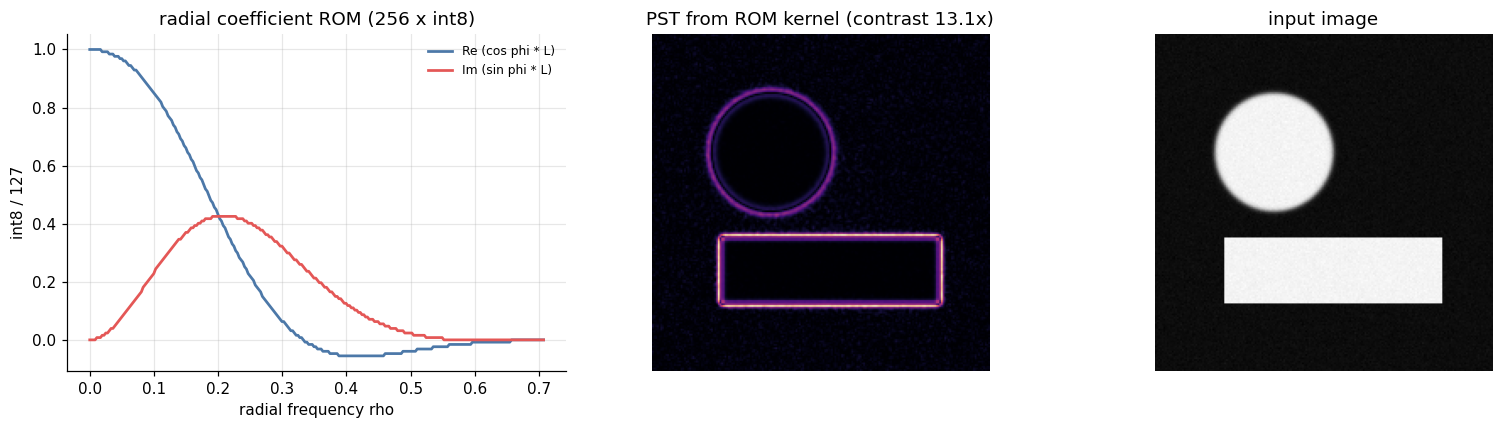

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(14.5, 4))
ax[0].plot(rbins, rom_re/127, color="#4C78A8", label="Re (cos phi * L)")
ax[0].plot(rbins, rom_im/127, color="#E45756", label="Im (sin phi * L)")
ax[0].set_xlabel("radial frequency rho"); ax[0].set_ylabel("int8 / 127")
ax[0].set_title("radial coefficient ROM (256 x int8)"); ax[0].legend(fontsize=8)
resp = np.abs(np.angle(np.fft.ifft2(np.fft.fft2(img)*kernel_rom)))
ax[1].imshow(resp, cmap="magma"); ax[1].set_title(f"PST from ROM kernel (contrast {c_rom:.1f}x)"); ax[1].axis("off")
ax[2].imshow(img, cmap="gray"); ax[2].set_title("input image"); ax[2].axis("off")
plt.tight_layout(); plt.show()

## Hardware notes

- **Radial symmetry is the win.** PST's kernel depends only on $\rho$, so a $2\times256$-byte 1-D ROM
  replaces the full 2-D mask; the only added logic is a $\rho(u,v)$ address, from a small
  $\sqrt{u^2+v^2}$ CORDIC or a second (u,v)->rho LUT.
- **PAGE** costs one more small 1-D ROM in $\theta$; the oriented coefficient is a product of two reads.
- **Registered read => BRAM**, one coefficient pair per clock, signed 8-bit (~48 dB) is plenty for edge
  contrast (verified: 7.2x vs 7.6x float). Swap kernels (new $S,W,\sigma$) by reloading the ROM.

## Summary

- The PST frequency-domain phase kernel becomes a **1-D int8 radial ROM** (isotropy collapses $N^2\to O(N)$);
  the reconstructed kernel keeps the edge contrast within a few percent of float.
- **PAGE** adds a **1-D angular ROM**; quantized, it still separates edge orientations.
- The coefficient ROM is emitted as **VHDL** (registered read for BRAM) and verified **bit-exact in Icarus
  Verilog** across all 256 addresses -- the FFT-domain-filter end of the Python -> C -> VHDL flow.

Subject-verb-object: isotropy shrinks the mask; the ROM stores the coefficients; the address selects
$\rho$; the FPGA filters at line rate.